# Capacidad del canal: ancho de banda, potencia y ruido

**Tema 3 · Apartados 3.1 · Demostración orientativa: 8–15 minutos.**

Explorar el límite de Shannon y distinguir aumentar el ancho de banda a SNR fija de hacerlo a potencia fija.

## Cómo experimentar

Ejecuta todo de arriba abajo. Cambia un parámetro, predice qué ocurrirá
y vuelve a ejecutar todas las celdas. En Jupyter: *Kernel → Restart Kernel and Run All Cells*;
en Colab: *Entorno de ejecución → Ejecutar todas*.

La vista HTML muestra los resultados guardados. Para recalcular se utiliza este cuaderno.
Los comentarios `#@param` permiten formularios en Colab; en Jupyter puedes editar los valores.
No se necesitan datos externos ni otros cuadernos. Las figuras y cálculos son deterministas.

## Modelo y pregunta

Para un canal AWGN ideal:
$$C=B\log_2\left(1+\frac{P}{N_0 B}\right).$$
$B$ se mide en Hz, $P$ es la potencia recibida en W y $N_0$ es la densidad de ruido
en W/Hz, con la convención de la teoría: la potencia de ruido integrada es $N=N_0B$.
La SNR que entra en la fórmula es **lineal**: $\mathrm{SNR}=10^{\mathrm{SNR}_{dB}/10}$.

Comparamos dos preguntas diferentes:

1. **SNR fija:** ¿qué ocurre al cambiar $B$? Mantener la SNR exige que $P$ aumente
   proporcionalmente a $B$ si $N_0$ no cambia.
2. **Potencia fija:** al aumentar $B$, también aumenta el ruido y disminuye la SNR.

$R_b$ es la tasa de **información**, antes de añadir redundancia. Para $R_b<C$,
el teorema permite error arbitrariamente pequeño con códigos adecuados y longitudes crecientes.
No especifica el código, su complejidad ni un retardo finito. La igualdad $R_b=C$ es la frontera;
no es una garantía práctica de funcionamiento.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## Parámetros

Modifica un valor cada vez. Los comentarios indican unidades y rangos.

In [2]:
#@title Parámetros
B_MHz = 2.0 #@param {type:"slider", min:0.2, max:10, step:0.2}
snr_db = 10.0 #@param {type:"slider", min:-10, max:30, step:1}
P_pW = 10.0 #@param {type:"slider", min:1, max:50, step:1}
N0_aW_Hz = 1.0 #@param {type:"slider", min:0.2, max:5, step:0.2}
Rb_Mbps = 5.0 #@param {type:"slider", min:0.5, max:30, step:0.5}
# MHz = 10^6 Hz; pW = 10^-12 W; aW/Hz = 10^-18 W/Hz.
assert 0.2 <= B_MHz <= 10 and -10 <= snr_db <= 30
assert 1 <= P_pW <= 50 and 0.2 <= N0_aW_Hz <= 5 and 0.5 <= Rb_Mbps <= 30

## 1. Capacidad frente a SNR

Comparamos el ancho de banda elegido con la mitad y el doble. La línea horizontal
marca la tasa de información deseada. Las intersecciones indican la SNR de frontera,
no la SNR que necesitará un código concreto.

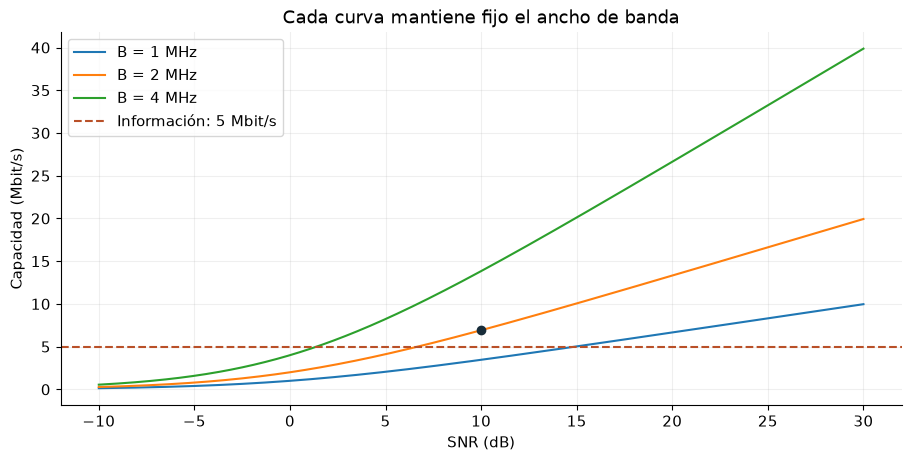

Punto elegido: C = 6.919 Mbit/s; frontera Rb = C a 6.68 dB.


In [3]:
snr_eje_db = np.linspace(-10,30,401)
snr_lineal = 10**(snr_eje_db/10)
fig, ax = plt.subplots(figsize=(9,4.5),layout="constrained")
for factor in [0.5,1,2]:
    banda = factor*B_MHz
    ax.plot(snr_eje_db,banda*np.log2(1+snr_lineal),label=f"B = {banda:g} MHz")
ax.axhline(Rb_Mbps,color="#b95028",ls="--",label=f"Información: {Rb_Mbps:g} Mbit/s")
C_snr = B_MHz*np.log2(1+10**(snr_db/10))
ax.scatter([snr_db],[C_snr],color="#172c3a",zorder=5)
ax.set(xlabel="SNR (dB)",ylabel="Capacidad (Mbit/s)",title="Cada curva mantiene fijo el ancho de banda")
ax.legend(); ax.grid(alpha=.2); plt.show()
snr_umbral = 10*np.log10(np.expm1(Rb_Mbps/B_MHz*np.log(2)))
print(f"Punto elegido: C = {C_snr:.3f} Mbit/s; frontera Rb = C a {snr_umbral:.2f} dB.")

## 2. ¿Qué cambia si la potencia es fija?

Para que la comparación sea justa, las curvas coinciden en $B=B_{\mathrm{elegido}}$.
La referencia a SNR fija usa la SNR que produce la potencia elegida en ese punto;
aquí **no se usa** el control `snr_db` de la primera figura.

La curva de potencia fija se aproxima a $P/(N_0\ln 2)$ cuando el ancho de banda crece.
No es una fórmula nueva de capacidad: es el límite de la misma expresión de Shannon.

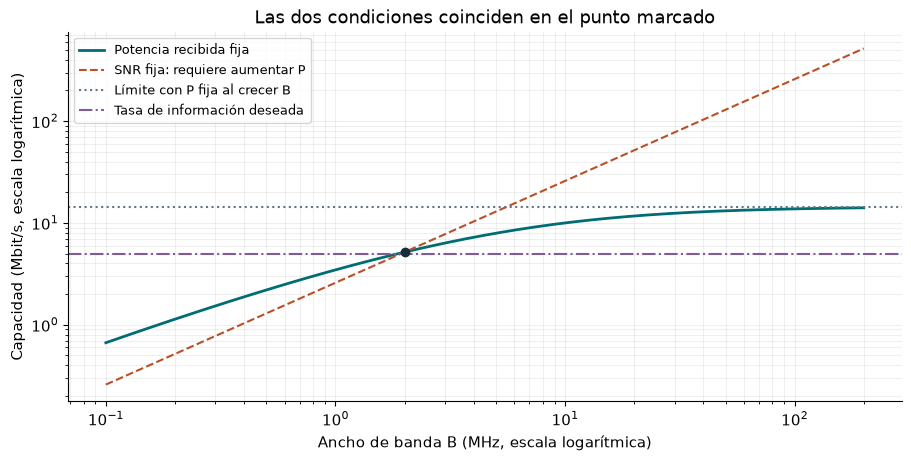

Con P fija, en B = 2 MHz: SNR = 6.99 dB.
C = 5.170 Mbit/s; límite al crecer B = 14.427 Mbit/s.
Rb < C: condición teórica satisfecha.


In [4]:
P = P_pW*1e-12
N0 = N0_aW_Hz*1e-18
B = B_MHz*1e6
bandas = np.geomspace(B/20,B*100,500)
snr_referencia = P/(N0*B)
C_potencia = bandas*np.log1p(P/(N0*bandas))/np.log(2)
C_snr_fija = bandas*np.log2(1+snr_referencia)
C_limite = P/(N0*np.log(2))
C_punto = B*np.log2(1+snr_referencia)
fig, ax = plt.subplots(figsize=(9,4.5),layout="constrained")
ax.plot(bandas/1e6,C_potencia/1e6,lw=2,color="#006d75",label="Potencia recibida fija")
ax.plot(bandas/1e6,C_snr_fija/1e6,ls="--",color="#b95028",label="SNR fija: requiere aumentar P")
ax.axhline(C_limite/1e6,color="#617583",ls=":",label="Límite con P fija al crecer B")
ax.axhline(Rb_Mbps,color="#805b96",ls="-.",label="Tasa de información deseada")
ax.scatter([B_MHz],[C_punto/1e6],color="#172c3a",zorder=5)
ax.set(xscale="log",yscale="log",xlabel="Ancho de banda B (MHz, escala logarítmica)",
       ylabel="Capacidad (Mbit/s, escala logarítmica)",title="Las dos condiciones coinciden en el punto marcado")
ax.legend(fontsize=9); ax.grid(alpha=.2,which="both"); plt.show()
print(f"Con P fija, en B = {B_MHz:g} MHz: SNR = {10*np.log10(snr_referencia):.2f} dB.")
print(f"C = {C_punto/1e6:.3f} Mbit/s; límite al crecer B = {C_limite/1e6:.3f} Mbit/s.")
print("Rb < C: condición teórica satisfecha." if Rb_Mbps < C_punto/1e6 else
      "Rb >= C: no estamos por debajo de la frontera teórica.")

## Antes de mirar la explicación

1. En la primera figura, ¿qué ocurre si se duplica B manteniendo la SNR?
2. En la segunda, ¿por qué las curvas se separan aunque coincidan en el punto marcado?
3. ¿Puede un aumento arbitrario de B compensar cualquier tasa deseada con P fija?
4. ¿Estar por debajo de C asegura que nuestro código tendrá una BER pequeña?

## Explicación de lo observado

1. La capacidad se duplica. Mantener la SNR con el doble de ruido exige el doble de potencia.
2. Con potencia fija, aumentar B reduce la SNR. Con SNR fija, la potencia aumenta con B.
3. No: aparece el límite $P/(N_0\ln 2)$. Con los valores originales es aproximadamente
   14.427 Mbit/s. En B = 2 MHz se obtienen unos 5.170 Mbit/s.
4. No. Shannon establece una posibilidad teórica, no las prestaciones de un código concreto.
   La comparación debe hacerse con la tasa de información y bajo el mismo modelo de canal.

## Comprobación del modelo

Comprobamos identidades y casos conocidos; estas celdas no sustituyen la interpretación.

In [5]:
assert np.isclose(1e6*np.log2(1+3),2e6)  # SNR lineal 3 y B = 1 MHz.
assert np.all(np.diff(C_potencia) > 0)
assert np.all(C_potencia < C_limite)
assert np.isclose(C_punto,B*np.log2(1+P/(N0*B)))
assert np.isclose(B_MHz*np.log2(1+10**(snr_umbral/10)),Rb_Mbps)
print("Conversión de SNR, frontera y límite de potencia comprobados.")

Conversión de SNR, frontera y límite de potencia comprobados.


## Referencias

Ejemplo y código propios para TDI.

- TDI, tema 3, apartados 3.1: «El límite de Shannon como referencia».
- J. G. Proakis y M. Salehi, *Digital Communications*, 5.ª ed., McGraw-Hill, 2008: codificación de canal.
- Los supuestos y las derivaciones particulares de este experimento se explican en «Modelo y pregunta».